# PCA-Weighted Swap Spread Curve & Fly Dislocation Backtest

Constructs **PCA-weighted butterflies and curves** on the MMSS swap spread term structure, then trades dislocations via the QueryDrivenBacktest framework.

**Methodology (per "Sweating the Small Stuff" + FI RV Analysis PCA chapter):**
1. Run rolling PCA on daily MMSS changes across benchmark tenors (2Y–30Y)
2. For each 3-tenor combination, extract PC3 (curvature eigenvector) → level+slope neutral butterfly weights
3. Compute weighted spread-to-curve (S2C) = weighted sum of PCA residuals
4. EMA smooth + z-score the S2C series (à la GSS framework: halflife smoothing + scoring)
5. Enter when |z| > threshold, exit on mean-reversion
6. Execute as matched-maturity swap spread trades (bond + CT-tenor swap per leg) with GC financing

**Spread convention:** spread = swap rate − treasury yield.
- **Buy spread:** buy bonds + pay swaps → profit when spread goes UP (narrows)
- **Sell spread:** sell bonds + receive swaps → profit when spread goes DOWN (widens)

**Fly convention:** Belly weight = 1 (normalized). Wings = PC3 loadings / belly loading.
- Positive belly z-score → belly spread is rich vs wings → sell belly spread, buy wing spreads

In [1]:
%load_ext autoreload
%autoreload 2

import datetime, sys, os, time, itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import QuantLib as ql

plt.style.use('ggplot')
pylab.rcParams.update({
    'legend.fontsize': 'x-large', 'figure.figsize': (18, 8),
    'axes.labelsize': 'x-large', 'axes.titlesize': 'x-large',
    'xtick.labelsize': 'large', 'ytick.labelsize': 'large',
})

sys.path.append('../../')

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements
from BT.query_tearsheet import QueryBacktestTearSheet

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from Query.FixedRateBonds.carry_roll import load_us_treasury_gc_fixing_pct
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

from BT.signals.tfp_swap_spread import CT_MAP, build_tfp_history
from BT.signals.irswap_pca_rv_scanner import (
    IRSwapPCARVConfig, _rolling_pca_surface, compute_fly_weights,
)
from RVUtils.plt_timeseries import make_secondary_axis_plot

## Config

In [2]:
cfg = dict(
    signal_start    = datetime.date(2020, 6, 1),
    bt_start        = datetime.date(2021, 6, 1),
    bt_end          = datetime.date(2026, 5, 14),

    # PCA
    pca_window      = 520,       # ~2yr rolling PCA window
    pca_input       = 'changes', # PCA on daily MMSS changes
    n_components    = 3,

    # GSS-style signal: EMA smooth then z-score
    smoothing_hl    = 3,         # EMA smoothing halflife (days)
    scoring_hl      = 30,        # z-score lookback halflife (days)
    z_entry         = 1.5,
    z_exit          = 0.25,
    max_hold        = 40,

    # Fly universe: all C(n,3) triples from these tenors
    tenors          = ['2Y', '3Y', '5Y', '7Y', '10Y', '30Y'],
    # Also include 2-leg curves
    include_curves  = True,

    # Spread type
    use_mmss        = True,

    # Risk
    risk_bpv        = 100_000,   # BPV per belly leg (wings scaled by PC3)
    unwind_fee_bps  = 0.5,
    specialness_bps = 10.0,

    # Data
    irs_source      = 'ERIS_EOD_LIVE-RL_BASIC',
    frb_source      = 'USTS_FEDINVEST_WSJ_LIVE-QL',
    cache_path      = os.path.abspath(os.path.join(
        os.getcwd(), '..', '..', 'BT', 'results', 'tfp_screener', 'tfp_history.parquet'
    )),
)

for k, v in cfg.items():
    print(f'  {k}: {v}')

  signal_start: 2020-06-01
  bt_start: 2021-06-01
  bt_end: 2026-05-14
  pca_window: 520
  pca_input: changes
  n_components: 3
  smoothing_hl: 3
  scoring_hl: 30
  z_entry: 1.5
  z_exit: 0.25
  max_hold: 40
  tenors: ['2Y', '3Y', '5Y', '7Y', '10Y', '30Y']
  include_curves: True
  use_mmss: True
  risk_bpv: 100000
  unwind_fee_bps: 0.5
  specialness_bps: 10.0
  irs_source: ERIS_EOD_LIVE-RL_BASIC
  frb_source: USTS_FEDINVEST_WSJ_LIVE-QL
  cache_path: c:\Users\chris\clee\ARBS\BT\results\tfp_screener\tfp_history.parquet


## Load MMSS Panel & Run Full-Curve PCA

In [3]:
history = pd.read_parquet(cfg['cache_path'])
history.index = pd.to_datetime(history.index)

mmss_panel = pd.DataFrame({
    t: history[f'mmss_{t}'] for t in cfg['tenors'] if f'mmss_{t}' in history.columns
}).dropna()
print(f'MMSS panel: {mmss_panel.shape}')

# Full-curve PCA for residuals
pca_cfg = IRSwapPCARVConfig(
    pca_window_days=cfg['pca_window'], pca_input=cfg['pca_input'],
    n_components=cfg['n_components'], zscore_lookback_days=cfg['scoring_hl'] * 5,
)
residuals, zscores_raw, var_exp, loadings_dict, reconstructed = _rolling_pca_surface(mmss_panel, pca_cfg)
print(f'PCA residuals: {residuals.notna().sum().min()} non-NaN dates')
print(f'Variance explained (3PC): {var_exp.dropna().tail(60).sum(axis=1).mean():.1%}')

MMSS panel: (1475, 6)
PCA residuals: 955 non-NaN dates
Variance explained (3PC): 95.4%


## Build Fly & Curve Universe with PCA Weights

For each 3-tenor combo, compute PC3 butterfly weights (level+slope neutral).
For 2-tenor curves, use residual z-score differential.

In [4]:
# GSS-style scoring: EMA smooth then z-score
def gss_zscore(series, smoothing_hl, scoring_hl):
    smoothed = series.ewm(halflife=smoothing_hl, min_periods=smoothing_hl).mean()
    mu = smoothed.ewm(halflife=scoring_hl, min_periods=scoring_hl).mean()
    sigma = smoothed.ewm(halflife=scoring_hl, min_periods=scoring_hl).std()
    return (smoothed - mu) / sigma.replace(0, np.nan)

# Build fly universe
fly_universe = []
fly_signals = {}

for left, belly, right in itertools.combinations(cfg['tenors'], 3):
    name = f'{left}/{belly}/{right}'
    
    # PC3 weights from the last available PCA
    rates_3 = mmss_panel[[left, belly, right]].dropna()
    if len(rates_3) < cfg['pca_window'] + 100:
        continue
    
    try:
        weights, eigvecs, (pc1_exp, pc2_exp) = compute_fly_weights(rates_3, pca_cfg)
    except (ValueError, np.linalg.LinAlgError):
        continue
    
    w_left, w_belly, w_right = weights
    
    # Weighted S2C: sum of PCA residuals × fly weights
    s2c = w_left * residuals[left] + w_belly * residuals[belly] + w_right * residuals[right]
    cum_s2c = s2c.cumsum()  # cumulative residual = the tradeable level
    
    # GSS z-score
    z = gss_zscore(cum_s2c.dropna(), cfg['smoothing_hl'], cfg['scoring_hl'])
    
    fly_universe.append(dict(
        name=name, kind='fly', legs=(left, belly, right),
        weights=(w_left, w_belly, w_right),
        pc1_exp=round(pc1_exp, 4), pc2_exp=round(pc2_exp, 4),
    ))
    fly_signals[name] = z

# Build curve universe (2-leg: residual z-score differential)
if cfg['include_curves']:
    for front, back in itertools.combinations(cfg['tenors'], 2):
        name = f'{front}/{back}'
        diff = residuals[back] - residuals[front]
        cum_diff = diff.cumsum()
        z = gss_zscore(cum_diff.dropna(), cfg['smoothing_hl'], cfg['scoring_hl'])
        
        fly_universe.append(dict(
            name=name, kind='curve', legs=(front, back),
            weights=(-1.0, 1.0),
            pc1_exp=np.nan, pc2_exp=np.nan,
        ))
        fly_signals[name] = z

print(f'Universe: {len(fly_universe)} packages')
n_fly = sum(1 for p in fly_universe if p['kind'] == 'fly')
n_curve = sum(1 for p in fly_universe if p['kind'] == 'curve')
print(f'  {n_fly} flies (PC3-weighted), {n_curve} curves')

# Show PC3 weights for flies
print(f'\n{"Package":>12s}  {"w_left":>7s}  {"w_belly":>7s}  {"w_right":>8s}  {"PC1 exp":>8s}  {"PC2 exp":>8s}')
for p in fly_universe:
    if p['kind'] != 'fly': continue
    w = p['weights']
    print(f'{p["name"]:>12s}  {w[0]:>7.3f}  {w[1]:>7.3f}  {w[2]:>8.3f}  {p["pc1_exp"]:>8.4f}  {p["pc2_exp"]:>8.4f}')

Universe: 35 packages
  20 flies (PC3-weighted), 15 curves

     Package   w_left  w_belly   w_right   PC1 exp   PC2 exp
    2Y/3Y/5Y   -0.283    1.000    -0.785   -0.0000    0.0000
    2Y/3Y/7Y   -0.482    1.000    -0.562    0.0000    0.0000
   2Y/3Y/10Y   -0.648    1.000    -0.408   -0.0000    0.0000
   2Y/3Y/30Y   -0.835    1.000    -0.199    0.0000    0.0000
    2Y/5Y/7Y   -0.144    1.000    -0.833   -0.0000   -0.0000
   2Y/5Y/10Y   -0.255    1.000    -0.755   -0.0000    0.0000
   2Y/5Y/30Y   -0.542    1.000    -0.453   -0.0000    0.0000
   2Y/7Y/10Y   -0.129    1.000    -0.911    0.0000   -0.0000
   2Y/7Y/30Y   -0.404    1.000    -0.625   -0.0000    0.0000
  2Y/10Y/30Y   -0.218    1.000    -0.764   -0.0000    0.0000
    3Y/5Y/7Y   -0.261    1.000    -0.708   -0.0000    0.0000
   3Y/5Y/10Y   -0.410    1.000    -0.591   -0.0000   -0.0000
   3Y/5Y/30Y   -0.722    1.000    -0.272    0.0000   -0.0000
   3Y/7Y/10Y   -0.231    1.000    -0.811    0.0000   -0.0000
   3Y/7Y/30Y   -0.583    

## Generate Entry/Exit Signals

In [5]:
# Signal: +1 = buy package (buy belly spread, sell wing spreads for flies)
#         -1 = sell package
# For flies: z > entry → belly rich → sell belly spread → direction = -1
#            z < -entry → belly cheap → buy belly spread → direction = +1

def gen_package_signal(z_series, z_entry, z_exit, max_hold):
    z = z_series.values
    sig = np.zeros(len(z), dtype=np.int8)
    pos = 0; hold = 0
    for i in range(len(z)):
        v = z[i]
        if np.isnan(v): sig[i]=0; pos=0; hold=0; continue
        if pos == 0:
            if v < -z_entry: pos = +1; hold = 0   # cheap → buy
            elif v > z_entry: pos = -1; hold = 0  # rich  → sell
        else:
            hold += 1
            ex = hold >= max_hold
            if not ex:
                if pos == +1 and v >= -z_exit: ex = True
                elif pos == -1 and v <= z_exit: ex = True
            if ex: pos = 0; hold = 0
        sig[i] = pos
    return pd.Series(sig, index=z_series.index)

# Generate signals and extract events
all_events = []
pkg_signals = {}

for pkg in fly_universe:
    name = pkg['name']
    if name not in fly_signals: continue
    z = fly_signals[name]
    sig = gen_package_signal(z, cfg['z_entry'], cfg['z_exit'], cfg['max_hold'])
    pkg_signals[name] = sig
    
    # Extract events (datetime.date for DateTriggerRequirements)
    sig_bt = sig.loc[cfg['bt_start']:cfg['bt_end']]
    dates = [d.date() if hasattr(d, 'date') else d for d in sig_bt.index]
    vals = sig_bt.values
    prev = 0; entry_date = None; direction = 0
    for i in range(len(vals)):
        cur = int(vals[i])
        if prev == 0 and cur != 0:
            entry_date = dates[i]; direction = cur
        elif prev != 0 and cur == 0:
            all_events.append(dict(
                entry_date=entry_date, exit_date=dates[i], direction=direction,
                pkg=name, legs=pkg['legs'], weights=pkg['weights'], kind=pkg['kind'],
                tag=f'pcafly-{name.replace("/","_")}-{entry_date}',
            ))
            entry_date = None; direction = 0
        elif prev != 0 and cur != 0 and cur != prev:
            all_events.append(dict(
                entry_date=entry_date, exit_date=dates[i], direction=direction,
                pkg=name, legs=pkg['legs'], weights=pkg['weights'], kind=pkg['kind'],
                tag=f'pcafly-{name.replace("/","_")}-{entry_date}',
            ))
            entry_date = dates[i]; direction = cur
        prev = cur
    if entry_date is not None:
        all_events.append(dict(
            entry_date=entry_date, exit_date=dates[-1], direction=direction,
            pkg=name, legs=pkg['legs'], weights=pkg['weights'], kind=pkg['kind'],
            tag=f'pcafly-{name.replace("/","_")}-{entry_date}',
        ))

# Summary
pkg_counts = {}
for ev in all_events:
    pkg_counts[ev['pkg']] = pkg_counts.get(ev['pkg'], 0) + 1

print(f'Total: {len(all_events)} trades across {len(pkg_counts)} packages')
for name, count in sorted(pkg_counts.items(), key=lambda x: -x[1])[:15]:
    kind = next(p['kind'] for p in fly_universe if p['name'] == name)
    print(f'  {name:>12s} ({kind}): {count} trades')

Total: 371 trades across 35 packages
      2Y/3Y/5Y (fly): 15 trades
     3Y/5Y/30Y (fly): 13 trades
         3Y/5Y (curve): 13 trades
        7Y/30Y (curve): 13 trades
     2Y/5Y/30Y (fly): 12 trades
     2Y/7Y/10Y (fly): 12 trades
     2Y/7Y/30Y (fly): 12 trades
    7Y/10Y/30Y (fly): 12 trades
        5Y/30Y (curve): 12 trades
        7Y/10Y (curve): 12 trades
     3Y/5Y/10Y (fly): 11 trades
     3Y/7Y/10Y (fly): 11 trades
    3Y/10Y/30Y (fly): 11 trades
         2Y/3Y (curve): 11 trades
         2Y/5Y (curve): 11 trades


## Build Triggers & Run QueryDrivenBacktest

Each fly trade = 2 legs per tenor (bond + swap). Flies have 3 tenors = 6 legs total.
Curves have 2 tenors = 4 legs total.
All legs tagged together for coordinated unwind.

Direction × weight determines each leg:
- Fly with direction=+1 (buy belly): belly gets `+bpv` bond / `-bpv` swap, wings get opposite scaled by PC3 weight
- The PC3 weights already encode the butterfly sign

In [6]:
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
tg = TimeGrid(ql_cal_date_range(ql_cal=CAL, start=cfg['bt_start'], end=cfg['bt_end']))

gc_fixing_pct = pd.Series(
    {d: load_us_treasury_gc_fixing_pct(d) for d in sorted({ts.date() for ts in tg})},
    dtype=float,
).sort_index().ffill().bfill()

financing_config = {
    'mode': 'gc_plus_specialness',
    'gc_rate': gc_fixing_pct / 100.0,
    'leg_specialness_bps': {'outright': cfg['specialness_bps']},
    'day_count': 'ACT/360',
    'haircut': 0.0,
}

frb_mdp = FixedRateBondsMDP(source=cfg['frb_source'])
irs_mdp = IRSwapsMDP(source=cfg['irs_source'])

# Build triggers
triggers = []
for ev in all_events:
    tag = ev['tag']
    direction = ev['direction']  # +1=buy package, -1=sell package
    legs = ev['legs']
    weights = ev['weights']
    
    entry_actions = []
    for leg_tenor, w in zip(legs, weights):
        ct = CT_MAP[leg_tenor]
        # direction * sign(w) = spread direction for this leg
        # For fly: direction=+1 (buy belly), w_belly=1 → spread_dir=+1 (buy belly spread)
        #          w_left<0, w_right<0 → spread_dir=-1 (sell wing spreads)
        spread_dir = direction * np.sign(w)
        leg_bpv = cfg['risk_bpv'] * abs(w) * spread_dir
        
        # Bond: buy if spread_dir > 0 (buy spread), sell if < 0 (sell spread)
        bond_q = FixedRateBondQuery(
            cusip=ct, value=FixedRateBondValue.NPV,
            structure_kwargs={'bpv': leg_bpv},
            meta={'financing': financing_config}, tags=(tag,),
        )
        # Swap: opposite direction for duration neutrality per leg
        swap_tenor = ct if cfg['use_mmss'] else leg_tenor
        swap_q = IRSwapQuery(
            curve='USD-SOFR-1D', tenor=swap_tenor, value=IRSwapValue.NPV,
            structure_kwargs={'bpv': -leg_bpv}, tags=(tag,),
        )
        entry_actions.extend([AddQueryAction(query=bond_q), AddQueryAction(query=swap_q)])
    
    n_legs = len(legs)
    triggers.append(DateTrigger(
        DateTriggerRequirements(dates=[ev['entry_date']]),
        actions=entry_actions,
    ))
    triggers.append(DateTrigger(
        DateTriggerRequirements(dates=[ev['exit_date']]),
        actions=[UnwindPositionsAction(match_tag=tag, fee=cfg['unwind_fee_bps'] * cfg['risk_bpv'] * n_legs)],
    ))

print(f'Triggers: {len(triggers)} ({len(all_events)} trades)')

Triggers: 742 (371 trades)


In [7]:
strategy = QueryStrategy(
    name=f"PCA Fly+Curve MMSS Dislocation",
    triggers=triggers,
    mdps={'FRB': frb_mdp, 'IRS': irs_mdp},
)

bt = QueryDrivenBacktest(time_grid=tg, strategy=strategy)
t0 = time.time()
bt.run()
print(f'Elapsed: {time.time()-t0:.0f}s')

BACKTESTING...:  50%|████▉     | 614/1239 [04:26<11:46,  1.13s/step]  L2 get failed for FixedRateBondPricer_Cache/04324f022b47
Traceback (most recent call last):
  File "c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\sqlalchemy\pool\base.py", line 1310, in _checkout
    raise exc.InvalidatePoolError()
sqlalchemy.exc.InvalidatePoolError: ()

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\sqlalchemy\engine\base.py", line 146, in __init__
    self._dbapi_connection = engine.raw_connection()
                             ~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\sqlalchemy\engine\base.py", line 3298, in raw_connection
    return self.pool.connect()
           ~~~~~~~~~~~~~~~~~^^
  File "c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\sqlalchemy\pool\base.py", line 449, in connect
    return _ConnectionFairy._checkout(self

The supplied `fixings` contain more fixings than were expected by the holiday calendar of the `curve`.
The additional fixing dates are shown in the underlying KeyError message below.
If the Series you are providing contains valid fixings the fault probably lies with Rateslib calendar definitions and should be reported.
This error can avoided by excluding these fixings using Series.pop().
"[Timestamp('2025-04-18 00:00:00')] not in index"


BACKTESTING...:  98%|█████████▊| 1211/1239 [15:20<00:42,  1.52s/step]

The supplied `fixings` contain more fixings than were expected by the holiday calendar of the `curve`.
The additional fixing dates are shown in the underlying KeyError message below.
If the Series you are providing contains valid fixings the fault probably lies with Rateslib calendar definitions and should be reported.
This error can avoided by excluding these fixings using Series.pop().
"[Timestamp('2026-04-03 00:00:00')] not in index"


BACKTESTING...: 100%|█████████▉| 1235/1239 [16:10<00:06,  1.58s/step]Failed to fetch pricer for CT3 @ 2026-05-12: asyncio.run() cannot be called from a running event loop
c:\Users\chris\clee\ARBS\notebooks\backtests\../..\MDP\FixedRateBonds\FixedRateBondsMDP.py:983: RuntimeWarning: coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited
  _logger.warning("Failed to fetch pricer for %s @ %s: %s", c, timestamp, e)
Failed to fetch pricer for 91282CQJ3 @ 2026-05-12: asyncio.run() cannot be called from a running event loop
c:\Users\chris\clee\ARBS\notebooks\backtests\../..\MDP\FixedRateBonds\FixedRateBondsMDP.py:983: RuntimeWarning: coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited
  _logger.warning("Failed to fetch pricer for %s @ %s: %s", c, timestamp, e)
BACKTESTING...: 100%|█████████▉| 1236/1239 [16:10<00:03,  1.25s/step]Failed to fetch pricer for CT3 @ 2026-05-13: asyncio.run() cannot be called from a running event l

"Missing FRB pricer for leg cusip='CT3'. available=[]"


Failed to fetch pricer for 91282CQJ3 @ 2026-05-13: asyncio.run() cannot be called from a running event loop
c:\Users\chris\clee\ARBS\notebooks\backtests\../..\MDP\FixedRateBonds\FixedRateBondsMDP.py:983: RuntimeWarning: coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited
  _logger.warning("Failed to fetch pricer for %s @ %s: %s", c, timestamp, e)
BACKTESTING...: 100%|█████████▉| 1237/1239 [16:10<00:01,  1.06step/s]c:\Users\chris\clee\ARBS\notebooks\backtests\../..\BT\query_engine.py:354: RuntimeWarning: coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited
  print(e)
BACKTESTING...: 100%|█████████▉| 1238/1239 [16:10<00:00,  1.42step/s]

"Missing FRB pricer for leg cusip='CT3'. available=[]"
asyncio.run() cannot be called from a running event loop


c:\Users\chris\clee\ARBS\notebooks\backtests\../..\BT\query_engine.py:354: RuntimeWarning: coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited
  print(e)
BACKTESTING...: 100%|██████████| 1239/1239 [16:11<00:00,  1.28step/s]

asyncio.run() cannot be called from a running event loop
Elapsed: 971s


## Results

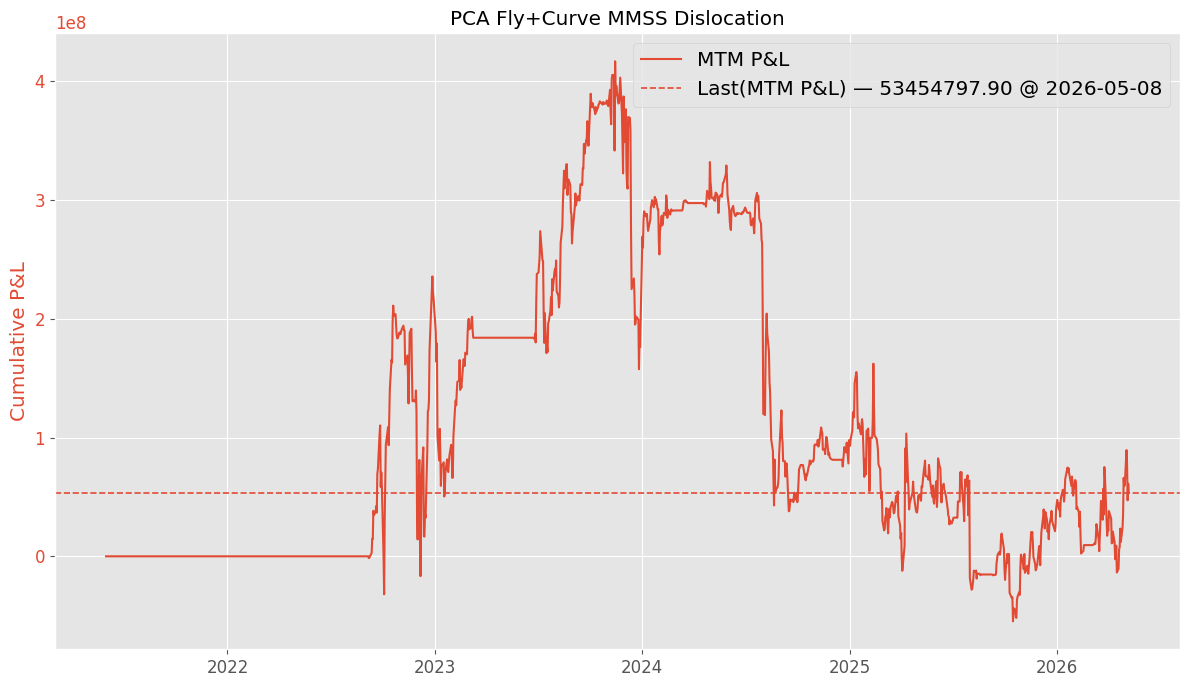

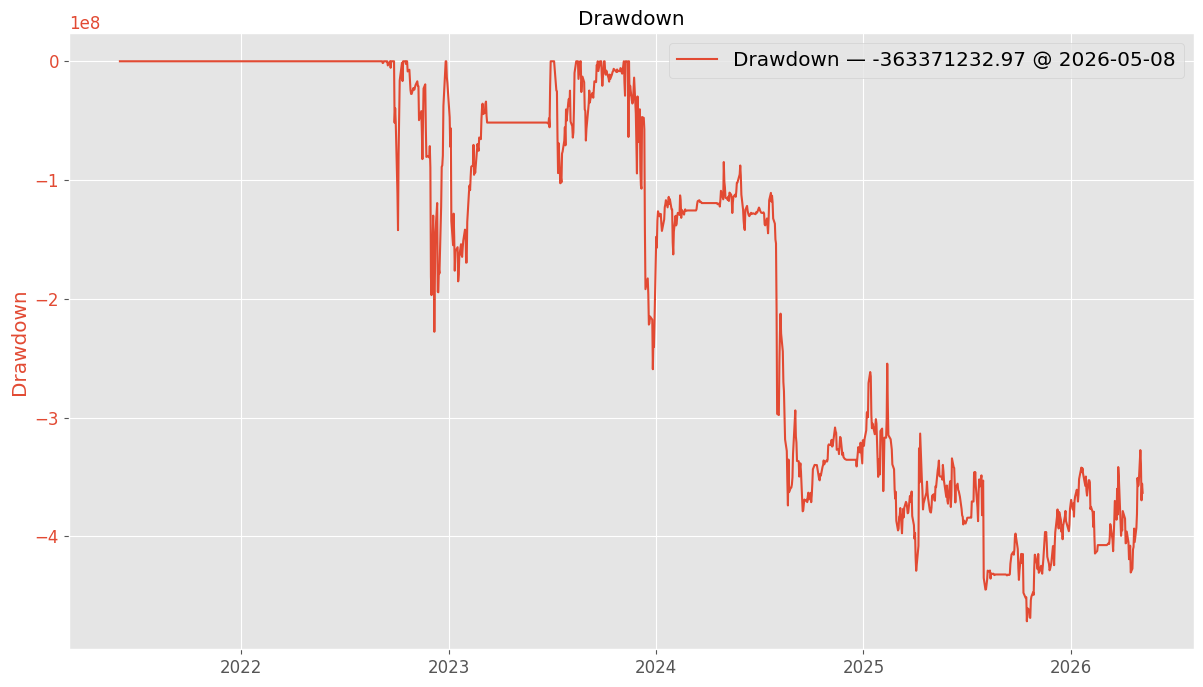

PCA window:   520d, smoothing_hl=3, scoring_hl=30
Signal:       z_entry=1.5, z_exit=0.25, max_hold=40
Risk BPV:     100,000

Final MTM:      53,454,798
Peak:          416,826,031
Max DD:       -471,529,762
Sharpe:               0.05
Daily vol:      14,180,307


In [8]:
mtm = pd.Series(bt.mtm_history).sort_index()
daily_pnl = mtm.diff().dropna()

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Cumulative P&L', title=strategy.name,
)
plot(mtm.rename('MTM P&L'), which='left', indicators=[
    {'kind': 'last', 'style': {'linestyle': '--', 'linewidth': 1.2}},
])
legend(show_date=True)
plt.show()

dd = mtm - mtm.cummax()
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Drawdown', title='Drawdown',
)
plot(dd.rename('Drawdown'), which='left')
legend(show_date=True)
plt.show()

sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0
max_dd = dd.min()

print(f'PCA window:   {cfg["pca_window"]}d, smoothing_hl={cfg["smoothing_hl"]}, scoring_hl={cfg["scoring_hl"]}')
print(f'Signal:       z_entry={cfg["z_entry"]}, z_exit={cfg["z_exit"]}, max_hold={cfg["max_hold"]}')
print(f'Risk BPV:     {cfg["risk_bpv"]:,}')
print(f'\nFinal MTM:    {mtm.iloc[-1]:>12,.0f}')
print(f'Peak:         {mtm.max():>12,.0f}')
print(f'Max DD:       {max_dd:>12,.0f}')
print(f'Sharpe:       {sharpe:>12.2f}')
print(f'Daily vol:    {daily_pnl.std():>12,.0f}')

## Closed Trades — By Package

In [9]:
closed = pd.DataFrame(bt.portfolio.closed_positions_log)

if not closed.empty:
    def _extract_tag(row):
        sq = row.get('source_query', None)
        if sq is not None and hasattr(sq, 'tags') and sq.tags:
            return sq.tags[0]
        pos = row.get('position', None)
        if pos is not None and hasattr(pos, 'source_query'):
            sq2 = pos.source_query
            if hasattr(sq2, 'tags') and sq2.tags:
                return sq2.tags[0]
        return None

    closed['tag'] = closed.apply(_extract_tag, axis=1)
    trade_pnl = closed.dropna(subset=['tag']).groupby('tag').agg(
        pnl=('realized_pnl', 'sum'), days=('holding_period_days', 'mean'),
    )
    # Extract package name from tag: pcafly-{name}-{date}
    trade_pnl['pkg'] = trade_pnl.index.str.extract(r'pcafly-(.+)-\d{4}')[0].values

    n = len(trade_pnl); w = (trade_pnl['pnl'] > 0).sum()
    print(f'Trades:     {n}')
    print(f'Winners:    {w} ({w/n:.0%})')
    ww = trade_pnl.loc[trade_pnl['pnl'] > 0, 'pnl']
    ll = trade_pnl.loc[trade_pnl['pnl'] <= 0, 'pnl']
    if len(ww): print(f'Avg win:    {ww.mean():>12,.0f}')
    if len(ll): print(f'Avg loss:   {ll.mean():>12,.0f}')
    print(f'Avg hold:   {trade_pnl["days"].mean():.0f}d')
    print(f'Total real: {trade_pnl["pnl"].sum():>12,.0f}')

    if trade_pnl['pkg'].nunique() > 1:
        print('\n--- By Package ---')
        ts = trade_pnl.groupby('pkg').agg(
            trades=('pnl', 'count'), total=('pnl', 'sum'),
            avg=('pnl', 'mean'), hit=('pnl', lambda x: f"{(x>0).mean():.0%}"),
            days=('days', 'mean'),
        ).sort_values('total', ascending=False)
        display(ts.head(20))
else:
    print('No closed trades.')

Trades:     362
Winners:    178 (49%)
Avg win:       4,915,134
Avg loss:     -4,557,516
Avg hold:   37d
Total real:   36,310,851

--- By Package ---


,trades,total,avg,hit,days
pkg,,,,,
3Y_5Y,13,4.200569e+07,3.231207e+06,62%,31.461538
2Y_3Y_5Y,15,3.802648e+07,2.535099e+06,73%,29.333333
3Y_10Y,10,3.152486e+07,3.152486e+06,70%,42.000000
2Y_5Y_10Y,9,2.936920e+07,3.263245e+06,78%,46.333333
3Y_5Y_30Y,13,2.936840e+07,2.259108e+06,69%,29.384615
5Y_10Y,11,2.908480e+07,2.644073e+06,55%,43.272727
2Y_7Y,8,2.331581e+07,2.914476e+06,50%,44.750000
2Y_7Y_10Y,11,2.145585e+07,1.950532e+06,73%,40.000000
7Y_10Y,11,2.085600e+07,1.896000e+06,82%,39.727273


## Financing Decomposition

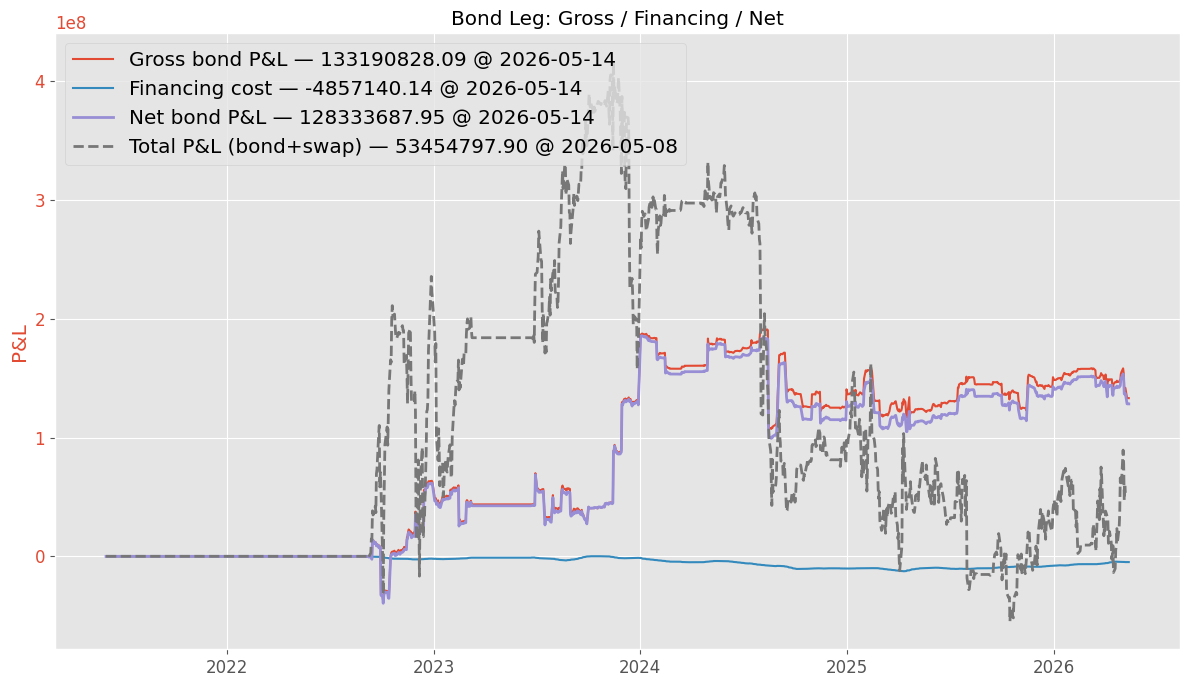

In [10]:
component_histories = getattr(bt, 'frb_component_histories', {})

if component_histories:
    time_index = pd.Index(list(tg), name='date')
    gross_bond = pd.Series(component_histories.get('bond_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)
    financing = pd.Series(component_histories.get('financing_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)
    net = pd.Series(component_histories.get('net_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)

    plot, fig, ax, ax2, legend = make_secondary_axis_plot(
        ylabel_left='P&L', title='Bond Leg: Gross / Financing / Net',
    )
    plot(gross_bond.rename('Gross bond P&L'), which='left')
    plot(financing.rename('Financing cost'), which='left')
    plot(net.rename('Net bond P&L'), which='left', linewidth=2)
    plot(mtm.rename('Total P&L (bond+swap)'), which='left', linewidth=2, linestyle='--')
    legend(show_date=True)
    plt.show()
else:
    print('No FRB component history available.')

## Tearsheet

In [11]:
try:
    tearsheet = QueryBacktestTearSheet.from_backtest(bt)
    plotly_fig = tearsheet.plot_plotly()
    plotly_fig.show()
except Exception as e:
    print(f'Tearsheet: {e}')